In [1]:
# %pylab
# import numpy
# np = numpy
# import matplotlib
# import matplotlib.cm as cm
%load_ext autoreload
%autoreload 2

from copy import deepcopy
import os,sys
from pathlib import Path

# numpy.set_printoptions(precision=3, threshold=1e6, linewidth=1e6)

# make a set of color maps with reasonable 'bad' values
# Dummy = type('Dummy', (object,), {})
# cmBad = Dummy()
# for name,attr in cm.__dict__.items():
#     if isinstance(attr, matplotlib.colors.LinearSegmentedColormap):
#         cmBad.__setattr__(name, deepcopy(attr))
#         cmBad.__getattribute__(name).set_bad(attr(0))

from ffluxHistsVsBFHistsExample import FFluxHistsVsBFHistsExample

In [2]:
figPath = Path('/Users/tel/roberts_lab/thesis/fall_2015_stuff/thesis_review_abstract_fall_2015/Figures')
defaultFilePath = '../../../../../regression/biphasic_switch.lm'

fflux_cppe3FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+03/genetic_toggle_switch.lm'
fflux_cppe4FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+04/genetic_toggle_switch.lm'
fflux_cppe5FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+05/genetic_toggle_switch.lm'
ffluxCppFileList = [fflux_cppe3FilePath, fflux_cppe4FilePath, fflux_cppe5FilePath]

ffluxRootPathLong = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+05'
ffluxRooPathInterfacesCount = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_vs_interfacesCount'

fflux_newCppe5FilePath = '../../../../../regression/tmp_genetic_toggle_switch.lm'

fflux_sweepPath = '/Users/tel/temp_data/gts_-_fflux_-_barrier_height_-_crossingsPerPhase_-_phaseZeroTime'
fflux_highQualSweepPath = '/Users/tel/temp_data/gts_-_fflux_-_crossingsPerPhase_-_phaseZeroTime_-_theta_-_replicate'

ffluxRootPath = defaultFilePath
ffluxRootPath = Path(fflux_highQualSweepPath)

example = FFluxHistsVsBFHistsExample(ffluxRootPath=ffluxRootPath, lmintOnly=True)

# example.ffluxHist = example.ffluxSims[('theta', '1.0e+00'), ('rep', '2')].peek().ffluxHists[(('InterfaceTilingID', 0), ('BinTilingIDs', (3,)))]
# example.ffluxHist2D = example.ffluxSims[('theta', '1.0e+00'), ('rep', '2')].peek().ffluxHists[(('InterfaceTilingID', 0), ('BinTilingIDs', (1,2)))]
# ffluxHist2D = next(example.ffluxSims.values().__iter__()).ffluxHists[(('InterfaceTilingID', 0), ('BinTilingIDs', (1,2)))]

In [3]:
dirName = 'splitCumSumBFHists'
extent = 8
frames = 180
n = 10000
figKwargs = {'figsize':(extent,)*2}
pltKwargs = {'vmin':1e-8, 'vmax':1e-1}

try:
    os.mkdir(dirName)
except OSError:
    pass

stride = int(n/frames)
for i,split in enumerate(reversed(example.bfHist.splitCumSum(n).ravel()[::stride])):
    split.normalize()
    split.plot(figKwargs=figKwargs, pltKwargs=pltKwargs);
    split.plotColorbar()
    split.ax.set_xlim(0,66)
    split.ax.set_ylim(0,66)
    
    figName = '%07d.png' % i
    figPath = os.path.join(dirName, figName)
    split.savefig(figPath)

/usr/local/lib/python3.4/site-packages/matplotlib/pyplot.py:516: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)
ERROR: 

Traceback (most recent call last):
  File "/usr/local/lib/python3.4/site-packages/IPython/core/interactiveshell.py", line 3066, in run_code
  File "<ipython-input-4-4d3b55e92056>", line 23, in <module>
    split.savefig(figPath)
  File "/Users/tel/git/lm/utils/python/lm_anal/lm_anal/src/plottable/plottable.py", line 113, in savefig
  File "/usr/local/lib/python3.4/site-packages/matplotlib/pyplot.py", line 688, in savefig
    res = fig.savefig(*args, **kwargs)
  File "/usr/local/lib/python3.4/site-packages/matplotlib/figure.py", line 1539, in savefig
  File "/usr/local/lib/python3.4/site-packages/matplotlib/backend_bases.py", line 2178, in print_figure
  File "/usr/local/lib/python3.4/site-packages/matplotlib/backends/backend_agg.py", line 527, in print_png
  File "/usr/local/lib/python3.4/site-packages/matplotlib/backends/backend_agg.py", line 474, in draw
  File "/usr/local/lib/python3.4/site-packages/matplotlib/artist.py", line 61, in draw_wrapper
  File "/usr/local/lib/python3.4/sit

Internal Python error in the inspect module.
Below is the traceback from this internal error.


Unfortunately, your original traceback can not be constructed.

ERROR: Internal Python error in the inspect module.
Below is the traceback from this internal error.


Unfortunately, your original traceback can not be constructed.



TypeError: 'NoneType' object is not iterable

(0, 66)

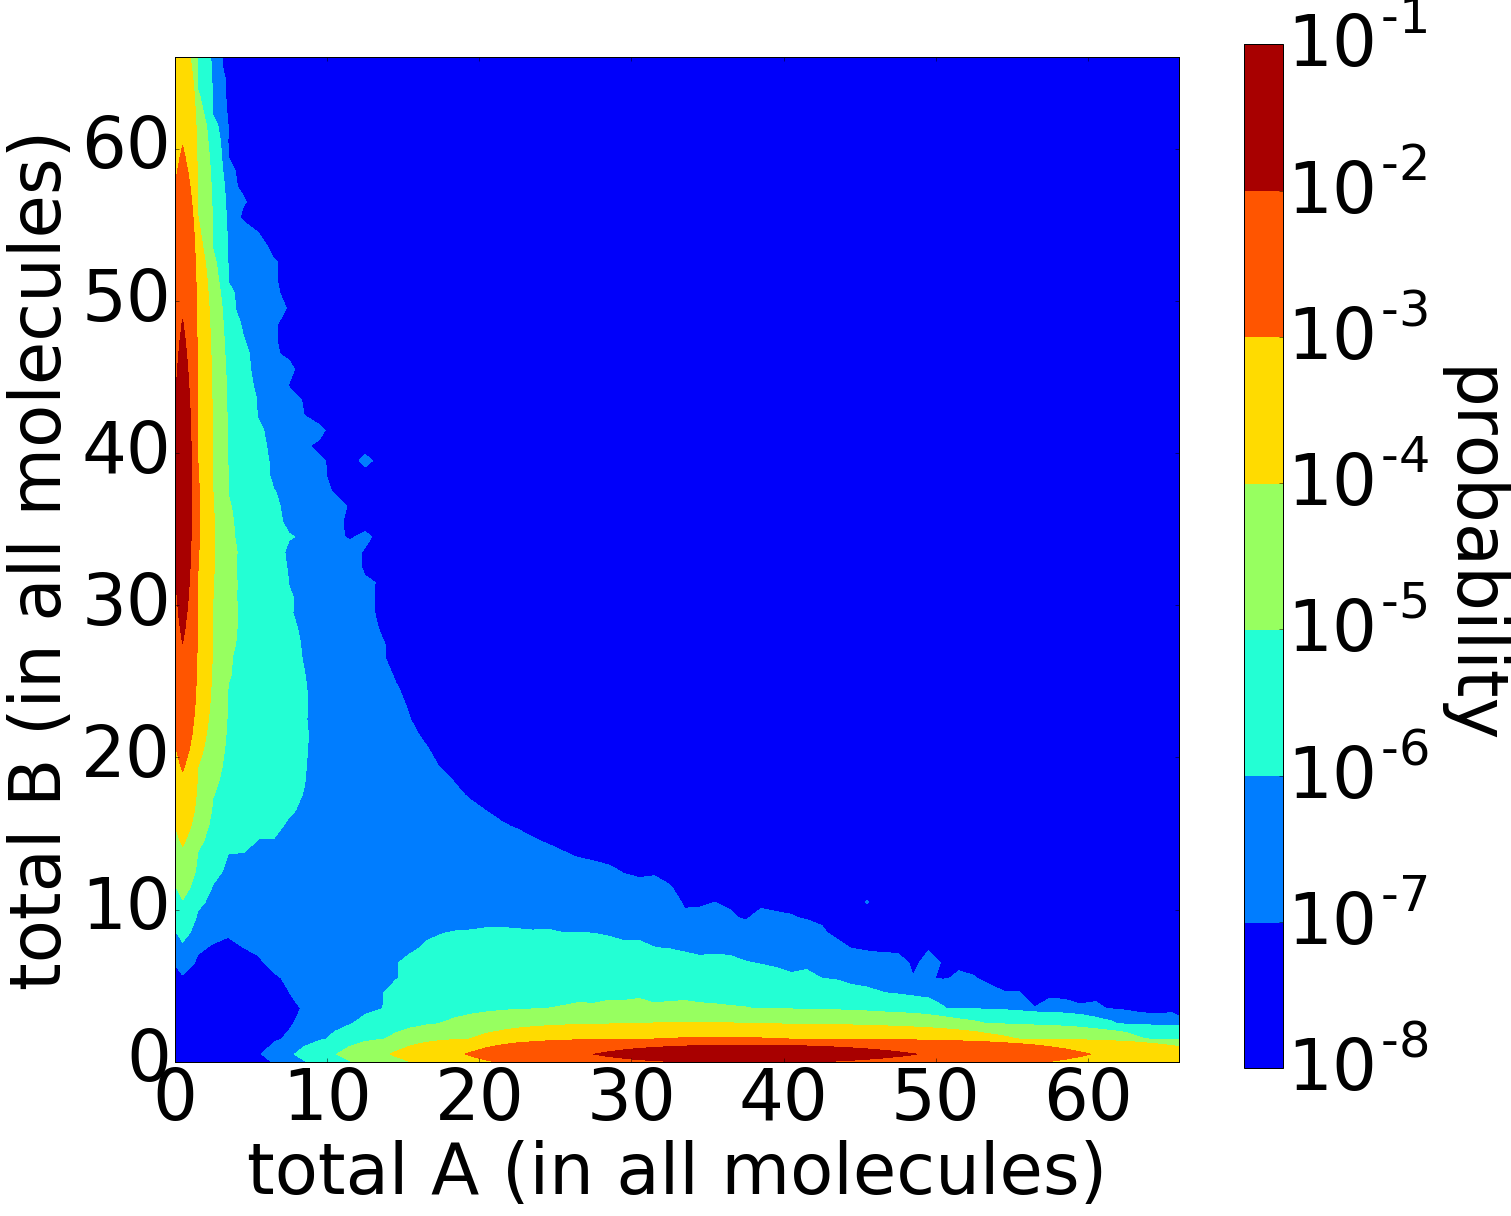

In [9]:
example.ffluxHist2D.plotContour(figKwargs={'figsize':(18,18)}, pltKwargs={'cmap':cm.jet})
example.ffluxHist2D.plotColorbar()
example.ffluxHist2D.ax.set_xlim(0,66)
example.ffluxHist2D.ax.set_ylim(0,66)

(0, 66)

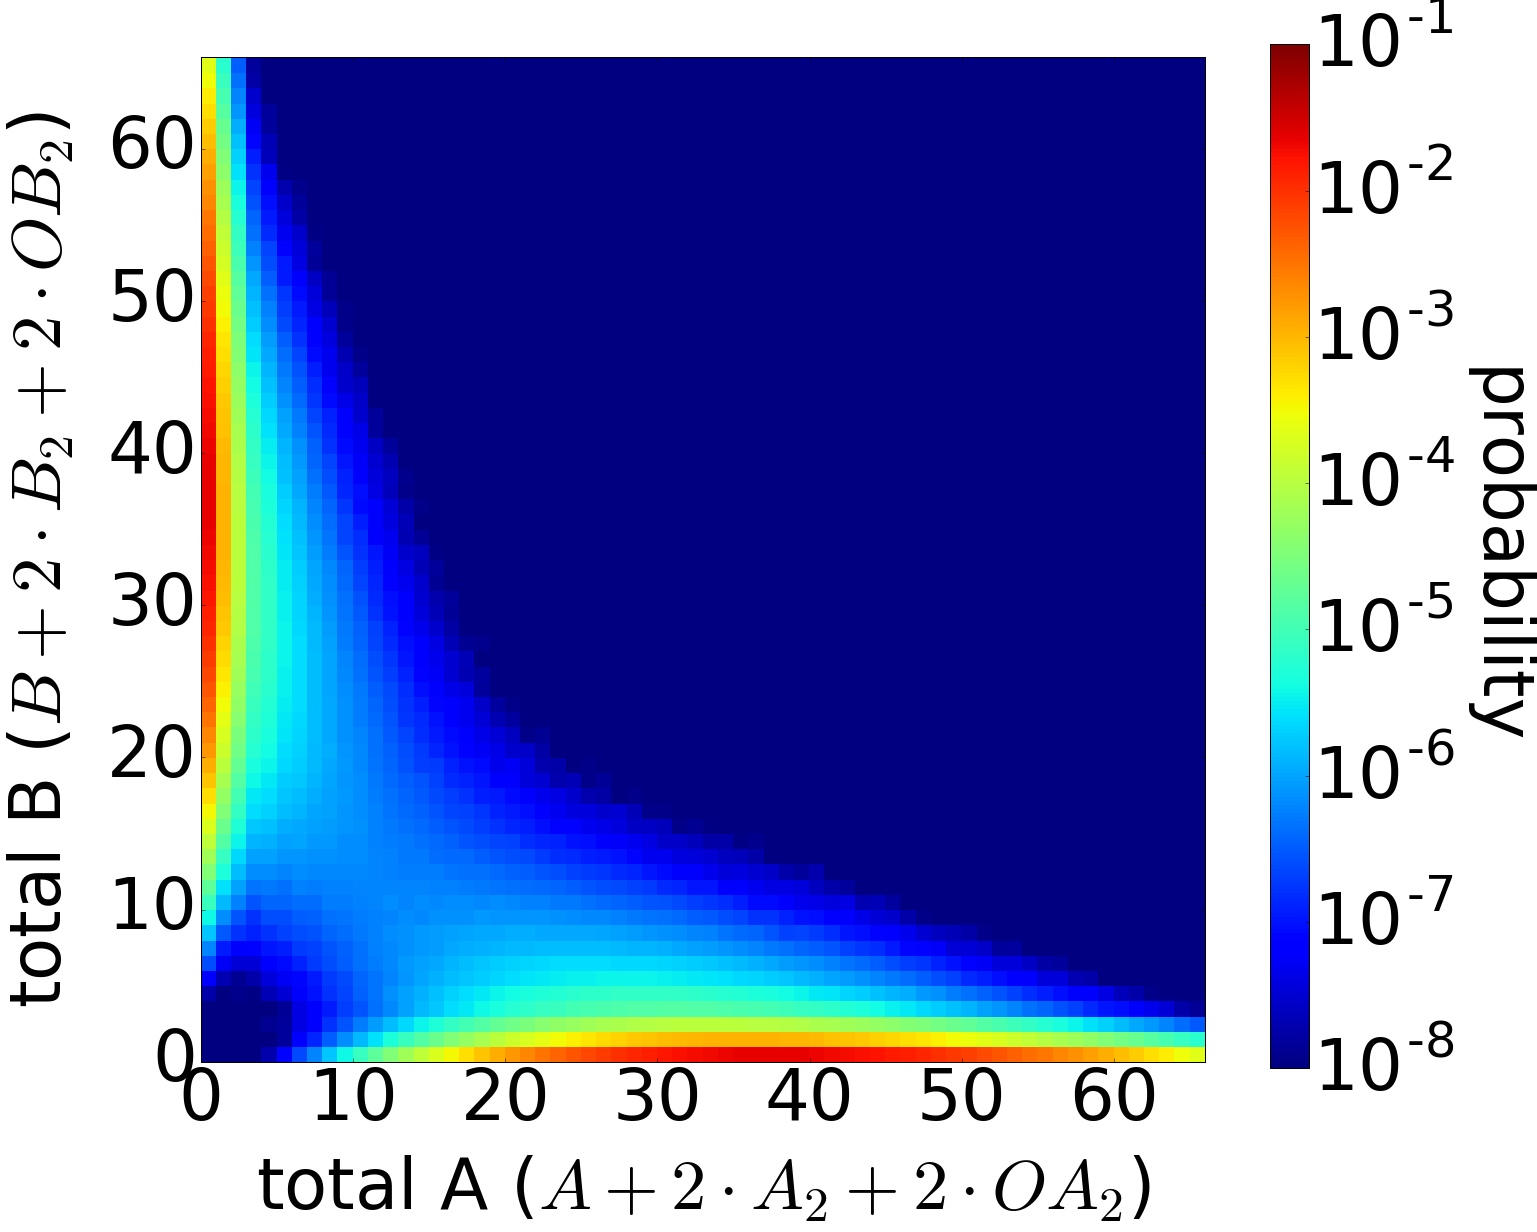

In [44]:
figKwargs = {'figsize':(18,18)}
pltKwargs = {'cmap':cmBad.jet, 'vmin':1e-8, 'vmax':1e-1}
example.bfHist.plot(figKwargs=figKwargs, pltKwargs=pltKwargs)
example.bfHist.plotColorbar()
example.bfHist.ax.set_xlim(0,66)
example.bfHist.ax.set_ylim(0,66)

In [29]:
forAbstract = False

example.bfHist.normalize()

stdErrArr = (example.bfHist.h - example.ffluxHist2D.h)/example.bfHist.h
stdErrHist = deepcopy(example.ffluxHist2D)
stdErrHist.h = stdErrArr

klDiv = example.bfHist.getKLDivergence(example.ffluxHist2D)
print(klDiv)
print(np.sum(example.bfHist.h))
print(np.sum(example.ffluxHist2D.h))

# klDivArr = example.bfHist.h*np.log(example.bfHist.h/example.ffluxHist2D.h)
# klDivArr[np.isnan(klDivArr)] = 0
# klDivArr[np.isinf(klDivArr)] = 0
# print(klDivArr.sum())

7.69854313058e-05
1.0
1.0


/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:5: RuntimeWarning: divide by zero encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:5: RuntimeWarning: invalid value encountered in true_divide
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4958165824
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4958165824
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4

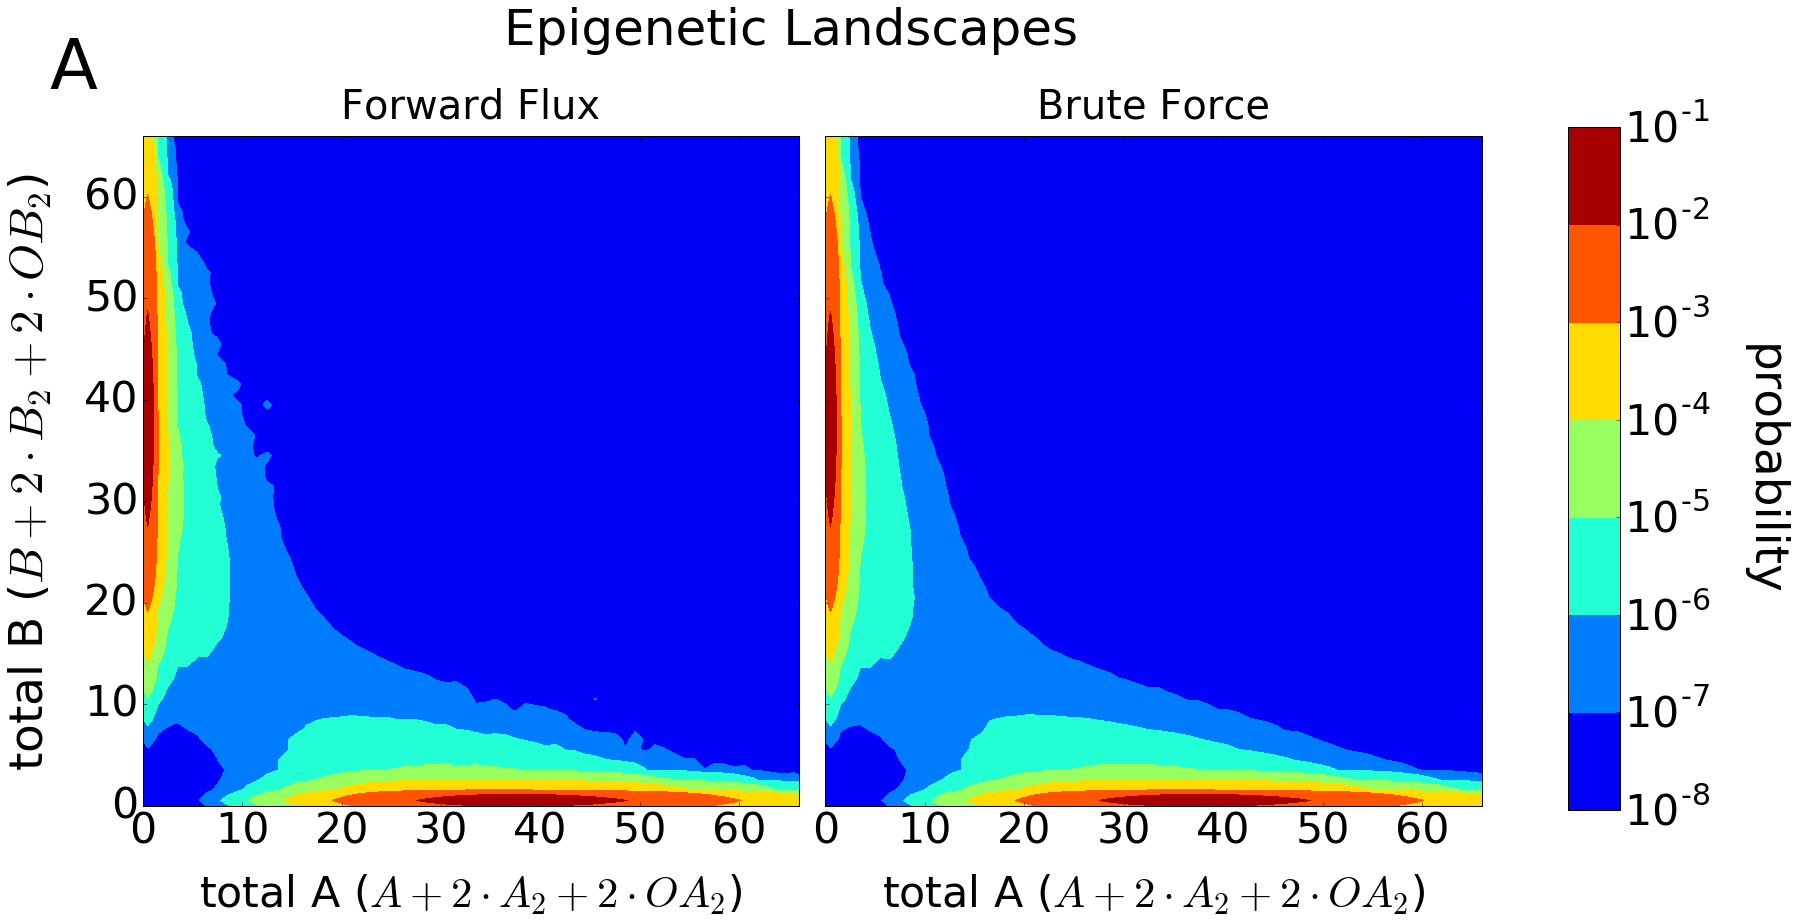

In [22]:
extent = 12
axArrShape = np.array((1, 2))
subplotsKwargs = {'figsize':axArrShape[::-1]*extent}
fig, axArr = plt.subplots(*axArrShape, sharex=True, sharey=True, **subplotsKwargs)

example.ffluxHist2D.plotContour(ax=axArr[0], fig=fig, pltKwargs={'cmap':cm.jet})
example.bfHist.plotContour(ax=axArr[1], fig=fig, pltKwargs={'cmap':cm.jet})
# stdErrHist.plotContour(ax=axArr[2], fig=fig, pltKwargs={'cmap':cm.jet})

titles = ['Forward Flux', 'Brute Force']
for i,(ax,title) in enumerate(zip(axArr.ravel(), titles)):
#     for b in (27,-27):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
    
    ax.set_xlim(0,66)
    ax.set_ylim(0,66)
    
    ax.set_title(title, fontsize=40, y=1.02)
    
    if i==0:
        pad = 5
        ax.annotate('A', xy=(-.15, 1.1), xytext=(pad, 0),
                    xycoords='axes fraction', textcoords='offset points',
                    size=70, ha='left', va='center')
    
    if i==1:
        ax.set_ylabel('')
    
example.ffluxHist2D.plotColorbar()
fig.subplots_adjust(wspace=.04)

fig.suptitle('Epigenetic Landscapes', fontsize=50, y=1.05)

plt.savefig(str(figPath / Path('ffluxVsBFHists.pdf')), bbox_inches='tight')

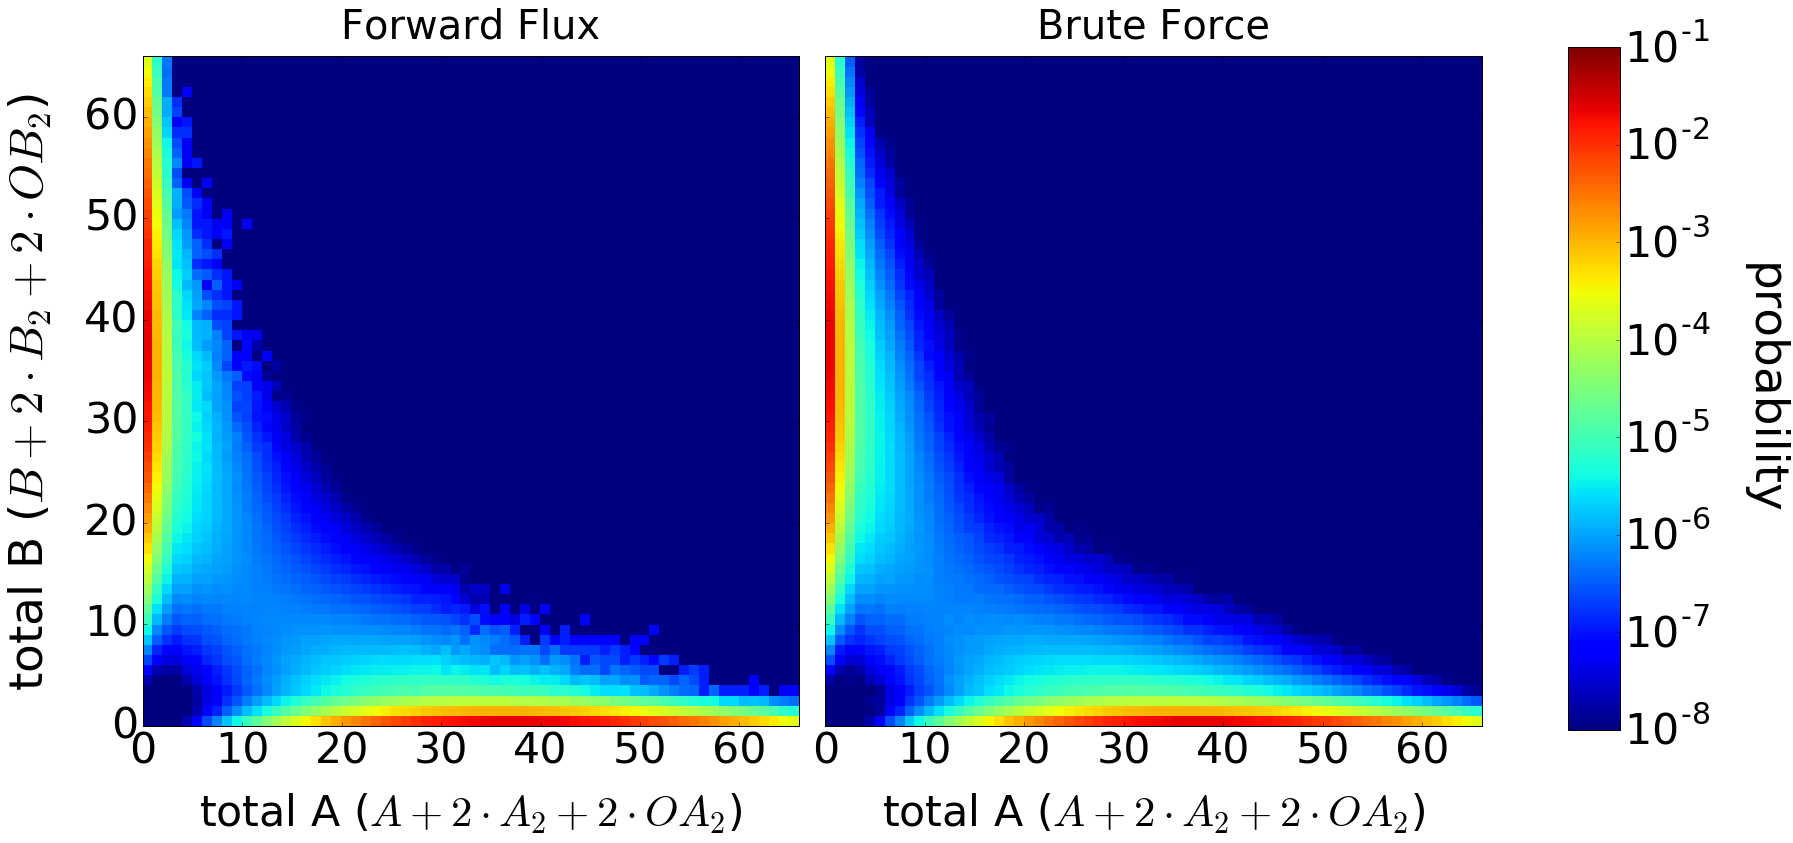

In [101]:
ffluxHist2D = example.ffluxSims[('theta', '1.0e+00'), ('rep', '0')].peek().ffluxHists[(('InterfaceTilingID', 0), ('BinTilingIDs', (1,2)))]

extent = 12
axArrShape = np.array((1, 2))
subplotsKwargs = {'figsize':axArrShape[::-1]*extent}
fig, axArr = plt.subplots(*axArrShape, sharex=True, sharey=True, **subplotsKwargs)

pltKwargs = {'cmap':cmBad.jet, 'vmin':1e-8, 'vmax':1e-1}
ffluxHist2D.plot(ax=axArr[0], fig=fig, pltKwargs=pltKwargs)
example.bfHist.plot(ax=axArr[1], fig=fig, pltKwargs=pltKwargs)
# stdErrHist.plotContour(ax=axArr[2], fig=fig, pltKwargs={'cmap':cm.jet})

titles = ['Forward Flux', 'Brute Force']
for i,(ax,title) in enumerate(zip(axArr.ravel(), titles)):
#     for b in (27,-27):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=5, dashes=(15,10)) 
    
    ax.set_xlim(0,66)
    ax.set_ylim(0,66)
    
    ax.set_title(title, fontsize=40, y=1.02)
    
    if i==1:
        ax.set_ylabel('')
    
ffluxHist2D.plotColorbar()
fig.subplots_adjust(wspace=.04)

# fig.suptitle('Epigenetic Landscapes', fontsize=50, y=1.05)

if 'forAbstract' in vars() and forAbstract:
    plt.savefig(str(figPath / Path('ffluxVsBFHists.pdf')), bbox_inches='tight')

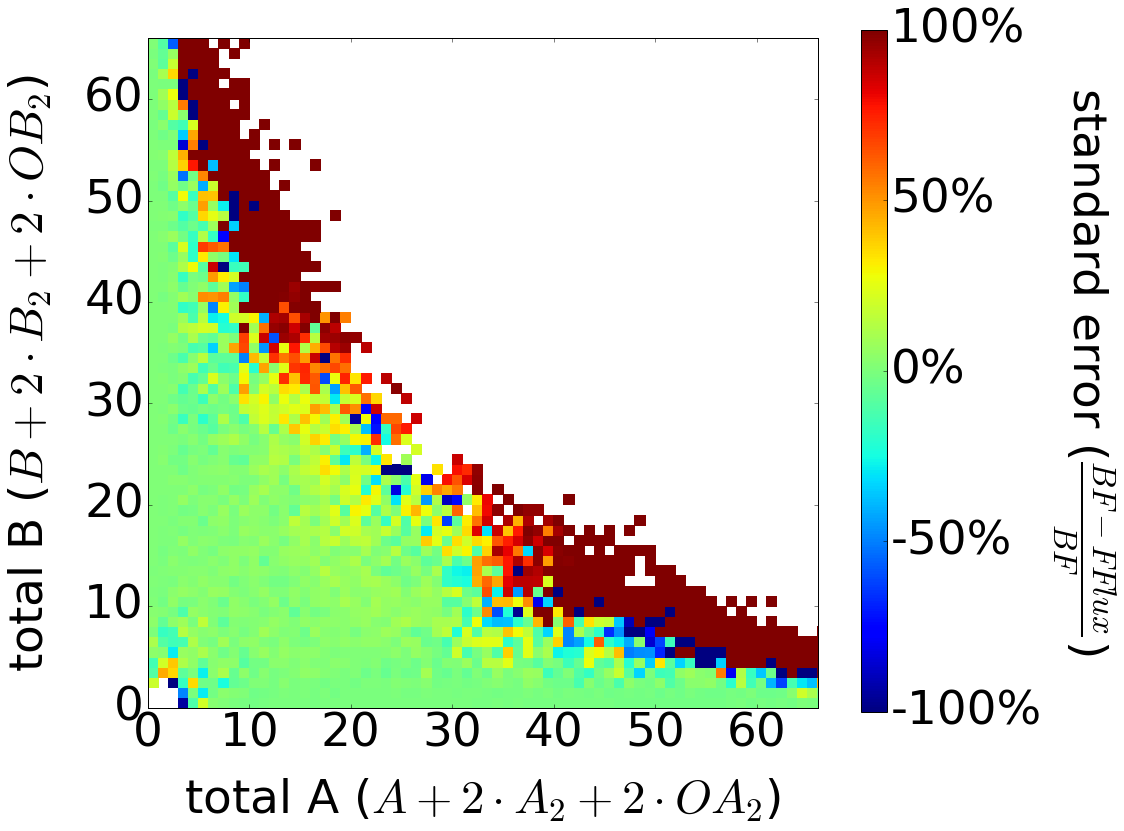

In [30]:
vmin = -1
vmax = 1

stdErrHist.h[np.isinf(stdErrHist.h)] = np.nan
stdErrHist.h = np.ma.array(stdErrHist.h, mask=np.isnan(stdErrHist.h))

# stdErrHist.plotContour(contourZeros=False, minLev=-1, maxLev=1, scale=None, figKwargs={'figsize':(18,18)}, pltKwargs={'cmap':cm.seismic})    #minLog=None, maxLog=None

figKwargs={'figsize':(12,12)}
pltKwargs = pltKwargs={'cmap':cm.jet, 'vmin':vmin, 'vmax':vmax}
stdErrHist.plot(scale=None, figKwargs=figKwargs, pltKwargs=pltKwargs)

t = np.linspace(vmin,vmax,5)
tickLabels = ['%d%%' % (tick*100) for tick in t]
cbOpts = {'ticks':t, 'format':'%.2f'}
stdErrHist.plotColorbar(label=r'standard error ($\frac{BF-FFlux}{BF}$)', **cbOpts)
stdErrHist.axCBar.get_yaxis().set_ticklabels(tickLabels)

stdErrHist.ax.set_xlim(0,66)
stdErrHist.ax.set_ylim(0,66)

if forAbstract:
    pad = 5
    stdErrHist.ax.annotate('B', xy=(-.20, 1.14), xytext=(pad, 0),
                           xycoords='axes fraction', textcoords='offset points',
                           size=60, ha='left', va='center')
    stdErrHist.fig.suptitle('Comparison of Brute Force\n and Forward Flux\ngenerated landscapes', fontsize=50, y=1.1)

    plt.savefig(str(figPath / Path('ffluxVsBFHistsStdErr.pdf')), bbox_inches='tight')

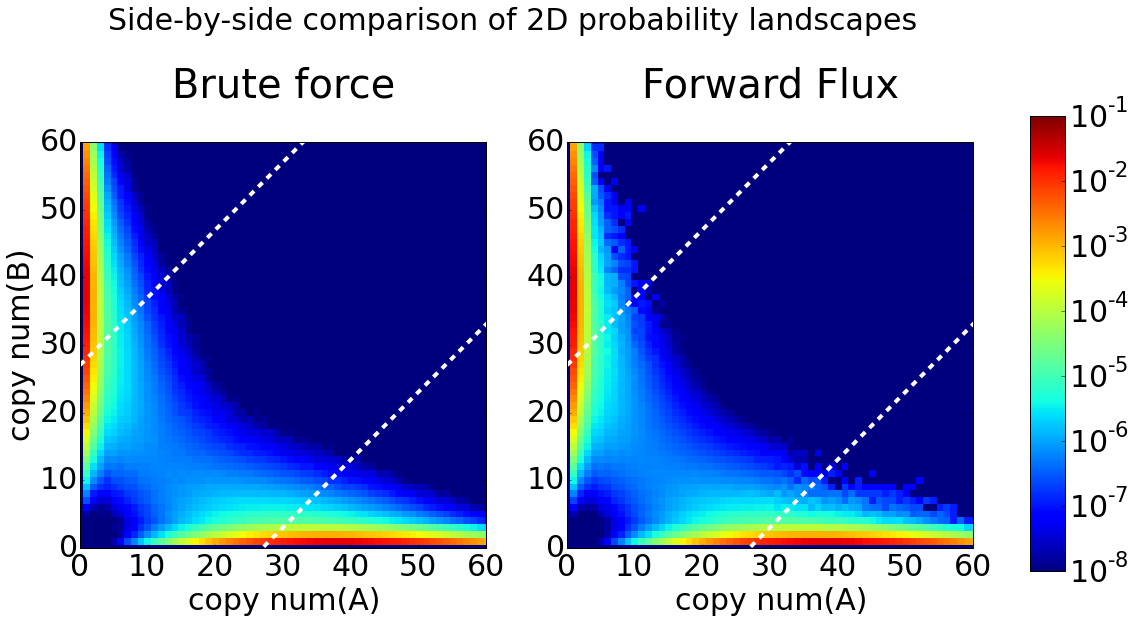

In [37]:
from matplotlib.colors import LogNorm
matplotlib.rcParams.update({'font.size': 30})

fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(16,8)
axcolor = fig.add_axes([0.95, 0.12, 0.03, 0.79])
titles = ['Brute force', 'Forward Flux']
for ax,hist,title in zip(axArr, (example.bfHist.h, example.ffluxHist2D.h), titles):
    t = np.logspace(-4,10,base=10,num=20)
#     ax.plot((1,2),(3,4))
    im = ax.matshow(hist, cmap=cm.jet, origin='lower',norm=LogNorm(), vmin=1e-8, vmax=1e-1)
    # to fix a .matshow() quirk
    ax.xaxis.set_ticks_position('bottom')

    for b in (27,-27):
        ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
#     for b in (25,-25):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
    ax.set_xlim(0,60)
    ax.set_ylim(0,60)
    ax.set_xlabel('copy num(A)')
#     ax.set_ylabel('copy num(B)')
    ax.set_title(title,  y=1.1, fontsize=40)
axArr[0].set_ylabel('copy num(B)')
fig.colorbar(im, cax=axcolor)#, ticks=t, format='$%.2e$')
fig.suptitle('Side-by-side comparison of 2D probability landscapes', y=1.1)

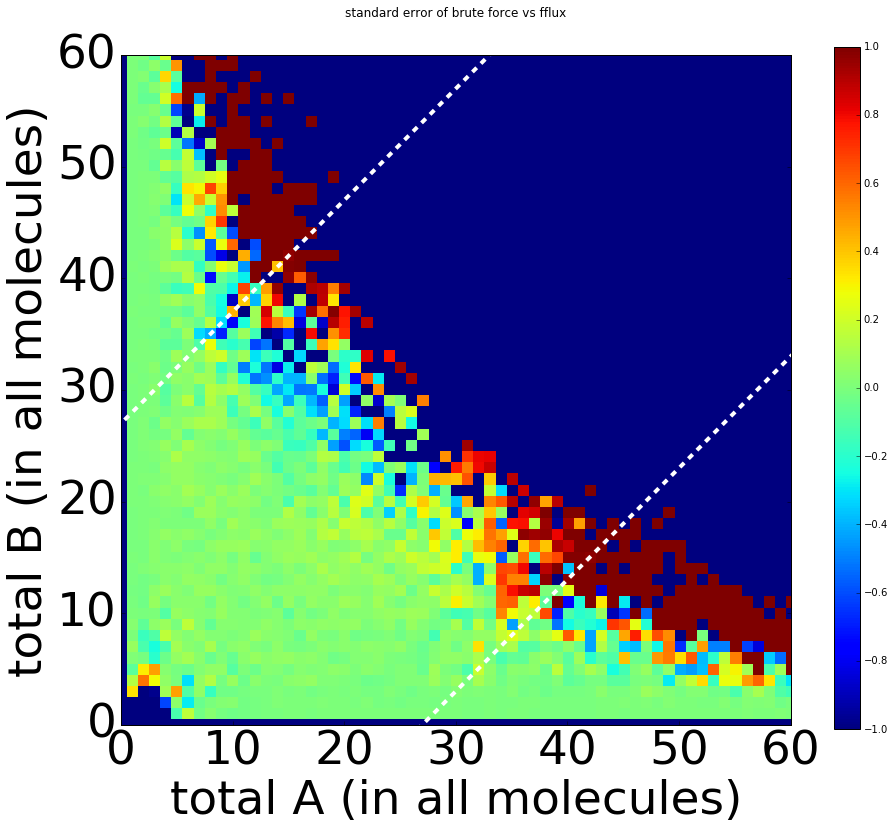

In [12]:
from matplotlib.colors import LogNorm

fig, ax, figKwargs, axesKwargs, pltKwargs = example.ffluxHist2D.plotSetup()
im = ax.matshow(stdErrArr, cmap=cm.jet, origin='lower',vmin=-1, vmax=1)# norm=LogNorm())
ax.xaxis.set_ticks_position('bottom')

for b in (27,-27):
    ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)

example.ffluxHist2D.plotColorbar(im)

ax.set_xlim(0,60)
ax.set_ylim(0,60)

ax.set_title('standard error of brute force vs fflux');

In [12]:
modFFluxArr = example.ffluxHist2D.basin_n_order_parameter_values[('basin_id', 0)].combine( \
              example.ffluxHist2D.basin_n_order_parameter_values[('basin_id', 1)])
modBFArr = example.bfHist.getCopy()

zeroMask = np.logical_or(modFFluxArr.h==0, modBFArr.h==0)
transitionMask = np.ones(modFFluxArr.h.shape, dtype=bool)
transitionMask[10:21,10:21] = False
# transitionMask = np.logical_and(transitionMask, zeroMask)

modBFArr.remask(transitionMask)
# modBFArr.normalize()
modFFluxArr.remask(transitionMask)
# modFFluxArr.normalize()
print(modBFArr.getKLDivergence(modFFluxArr, normalize=True))

modBFArr.remask(zeroMask)
modBFArr.normalize()
modFFluxArr.remask(zeroMask)
modFFluxArr.normalize()
klDivTransition = modBFArr.getKLDivergence(modFFluxArr)
print(klDivTransition)

print(np.sum(modFFluxArr.h))
print(np.sum(modBFArr.h))
print(np.all(modFFluxArr.h.nonzero()[0]==modBFArr.h.nonzero()[0]))
print(np.all(modFFluxArr.h.nonzero()[1]==modBFArr.h.nonzero()[1]))
print(np.any((modFFluxArr.h==modBFArr.h)))
print(np.any(np.isnan((modBFArr.h - modFFluxArr.h)/modBFArr.h)))
stdErrArr = (modBFArr.h - modFFluxArr.h)/modBFArr.h
klDivArr = modBFArr.h*np.log(modBFArr.h/modFFluxArr.h)
klDivArr[np.isnan(klDivArr)] = 0

bfStdErrArr = (modBFArr.h - modBFArr.h.T)/modBFArr.h
bfKLDivArr = modBFArr.h*np.log(modBFArr.h/modBFArr.h.T)
bfKLDivArr[np.isnan(bfKLDivArr)] = 0

ffStdErrArr = (modFFluxArr.h - modFFluxArr.h.T)/modFFluxArr.h
ffKLDivArr = modFFluxArr.h*np.log(modFFluxArr.h/modFFluxArr.h.T)
ffKLDivArr[np.isnan(ffKLDivArr)] = 0

print(klDivArr.sum())
print(klDivArr[10:21,10:21].sum())

0.000743717045546
4.20735057087e-05
1.0
1.0
True
True
True
True
4.20735057089e-05
2.09162883805e-05


/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:27: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:28: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:29: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:32: RuntimeWarning: divide by zero encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:32: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:33: RuntimeWarning: divide by zero encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:33: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:33: RuntimeWarning: divide by zero encountered in log
/usr/local/lib/python3.4/site

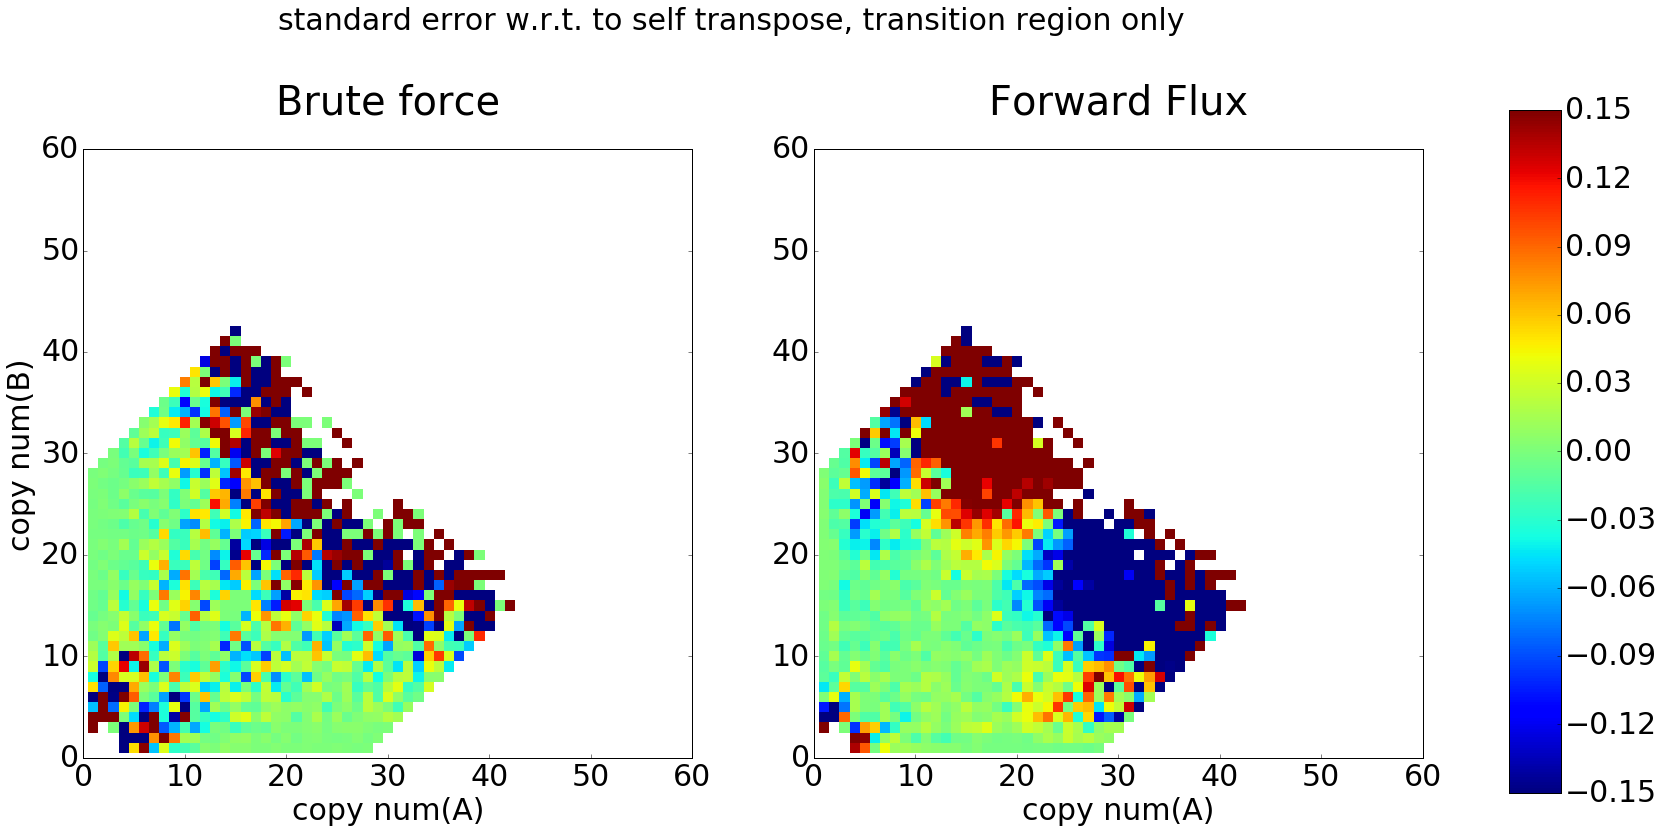

In [13]:
matplotlib.rcParams.update({'font.size': 30})

extent = 12
fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(2*extent, 1*extent)
axcolor = fig.add_axes([0.95, 0.12, 0.03, 0.79])
titles = ['Brute force', 'Forward Flux']

for ax,hist,title in zip(axArr, (bfStdErrArr, ffStdErrArr), titles):
    #     ax.plot((1,2),(3,4))
    im = ax.matshow(hist, cmap=cm.jet, origin='lower',vmin=-.15, vmax=.15)#, norm=LogNorm(), vmin=1e-8, vmax=1e-1)
    ax.xaxis.set_ticks_position('bottom')
    
#     for b in (25,-25):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
    t = np.logspace(-4,10,base=10,num=20)
    fig.colorbar(im, cax=axcolor, ticks=t, format='$%.2e$')
    ax.set_xlim(0,60)
    ax.set_ylim(0,60)
    ax.set_xlabel('copy num(A)')
#     ax.set_ylabel('copy num(B)')
    ax.set_title(title, fontsize=40)
axArr[0].set_ylabel('copy num(B)')
fig.colorbar(im, cax=axcolor)
fig.suptitle('standard error w.r.t. to self transpose, transition region only', y=1.03)

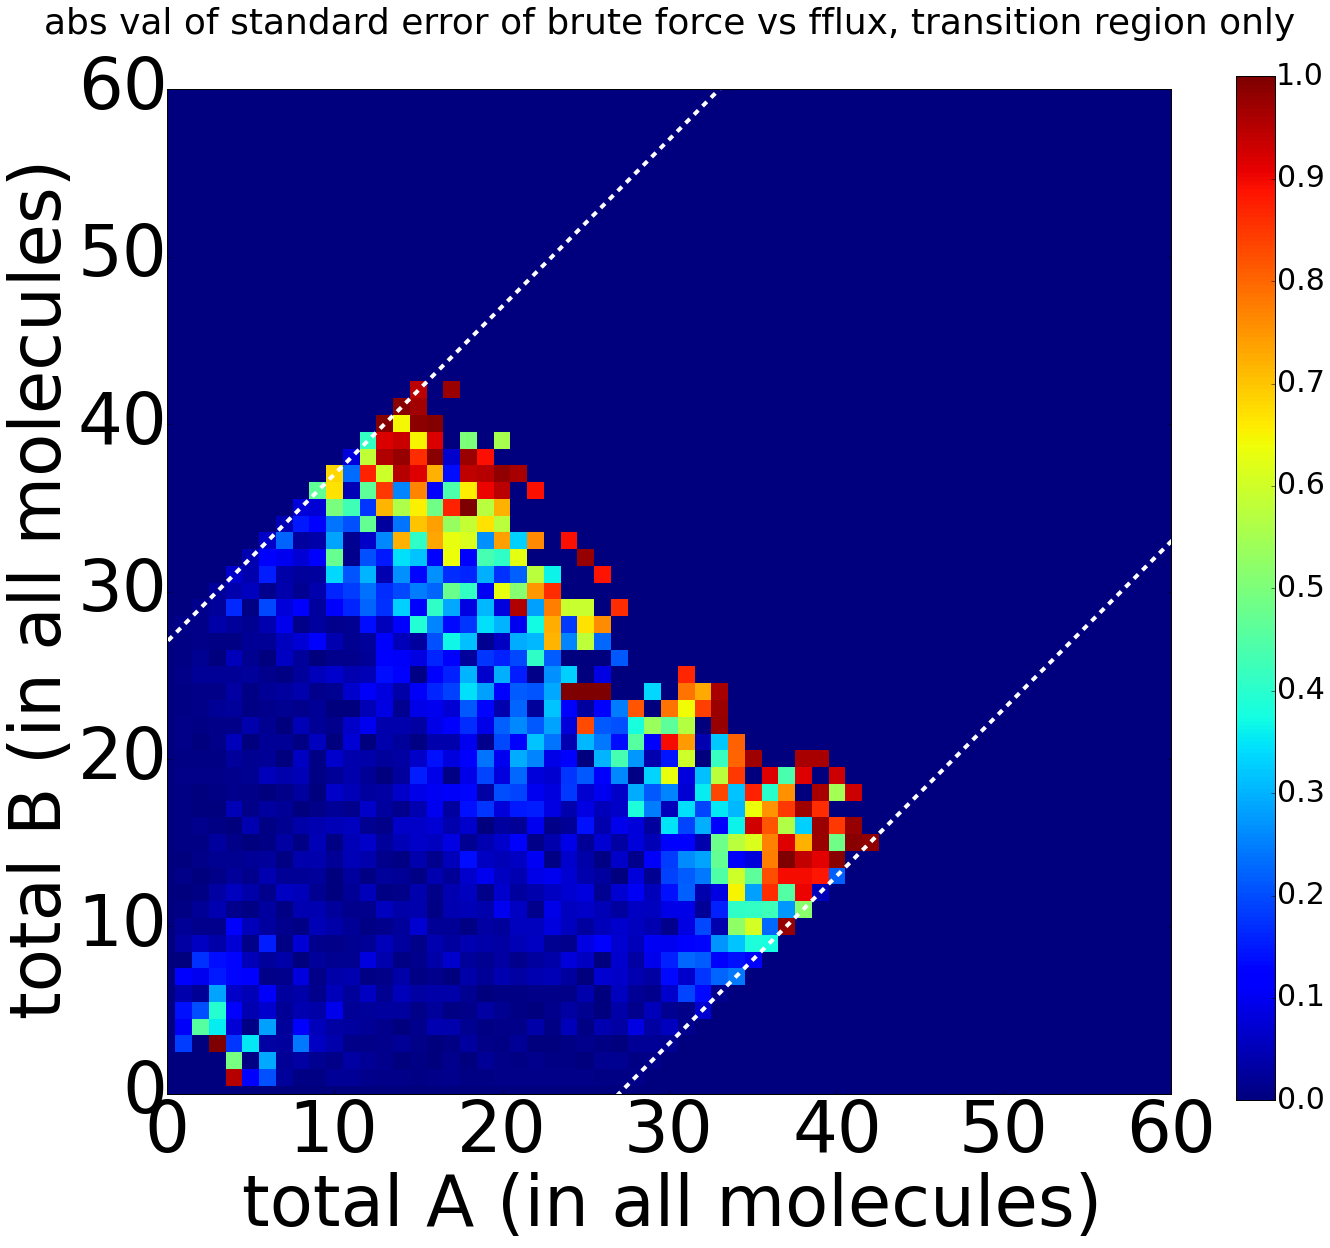

In [28]:
from matplotlib.colors import LogNorm
figKwargs={'figsize':(18,18)}

fig, ax, figKwargs, axesKwargs, pltKwargs = example.ffluxHist2D.plotSetup(figKwargs=figKwargs)
im = ax.matshow(np.abs(stdErrArr), cmap=cm.jet, origin='lower',vmin=0, vmax=1) #, norm=LogNorm())
ax.xaxis.set_ticks_position('bottom')

for b in (27,-27):
    ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)

example.ffluxHist2D.plotColorbar(im)
    
ax.set_xlim(0,60)
ax.set_ylim(0,60)

ax.set_title('abs val of standard error of brute force vs fflux, transition region only');

In [26]:
# resample_count = np.logspace(2, 8, num=7)
# resample_klDiv = [0.22115484214190989, 0.058052515738895256, 0.0097402208107240529, 0.0019470898399369212, 0.00038031473057596884, 6.0862781067080629e-05, 8.6023991989453894e-06]
dim = 2
theta = '1.0e+00'
ffluxHistsKey = (('InterfaceTilingID', 0), ('BinTilingIDs', (1,2))) if dim==2 else (('InterfaceTilingID', 0), ('BinTilingIDs', (3)))

example.genStdKLDivWithSplit(dim=dim, nDownsampled=7, theta=theta)
# example.genStdKLDivBetweenBasins()

example.genKLDiv(dim=2, mask1DExtremes=74, normalize='mask')
ffluxReps = example.ffluxSims[('theta', theta)].ffluxHists.getItem(ffluxHistsKey)
ffluxKLDiv = ffluxReps.klDiv.getValues()

999985541.0
1000014658.0
100 finished took 0.0006539821624755859 seconds
1000 finished took 0.0009191036224365234 seconds
10000 finished took 0.0026149749755859375 seconds
100000 finished took 0.016244888305664062 seconds
1000000 finished took 0.1489238739013672 seconds
10000000 finished took 1.4984080791473389 seconds
100000000 finished took 17.91031789779663 seconds
klDivDict contents:

Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4958515992
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4958515992
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4677826312
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py


[100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 'original']
[0.25331293998792287, 0.068349877946551715, 0.010252014151258001, 0.0020142488159670463, 0.00039305958699408509, 6.8798394406646951e-05, 9.435611945711569e-06, 1.868126148448405e-06]


'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4958519016
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4958519016
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4958515704
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)

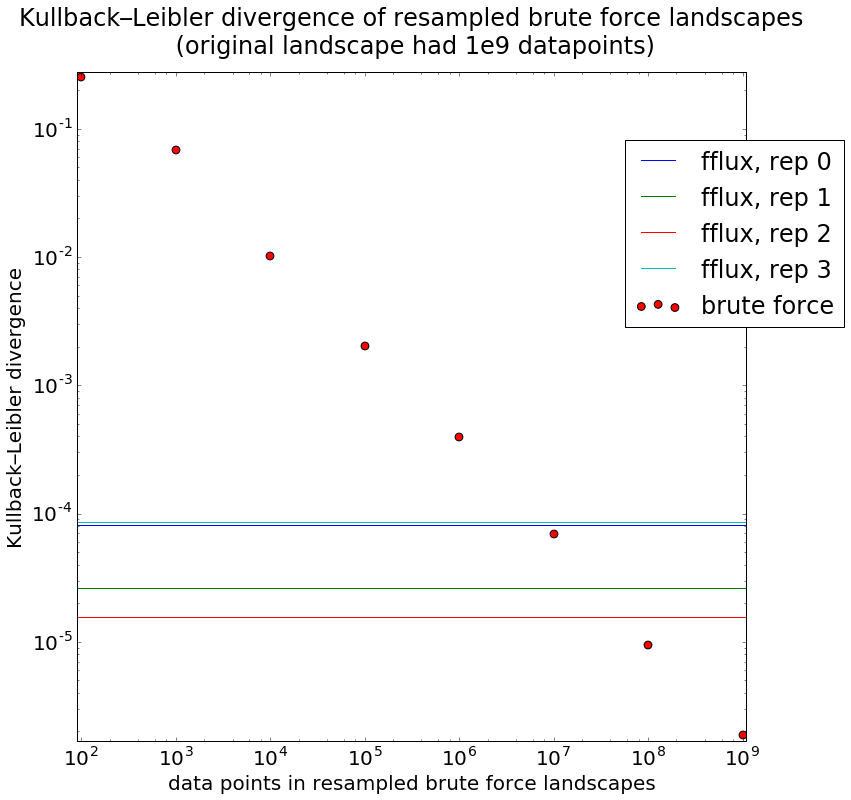

In [27]:
matplotlib.rcParams.update({'font.size': 20, 'axes.formatter.limits':(-4,4)})

fig = figure(figsize=(12,12))
ax = fig.gca()
resample_count,resample_klDiv = [list(tup) for tup in zip(*example.klDivDict.items())]               #list(zip(*list(example.klDivDict.items())[:-1]))
resample_count[-1] = 1e9

ax.scatter(resample_count, resample_klDiv, c='r', s=60, label='brute force')
horiz_line_x = (min(resample_count) - .1*min(resample_count), max(resample_count) + .1*max(resample_count))
for i,klDiv in enumerate(ffluxKLDiv):
    ax.plot(horiz_line_x, [klDiv]*2, label='fflux, rep %d' % i)
# ax.plot(horiz_line_x, [klDivTransition]*2, label='forward flux, transition only')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='lower left', bbox_to_anchor=(0.8, 0.6))
ax.set_xlim(min(resample_count) - .1*min(resample_count), max(resample_count) + .1*max(resample_count))
ax.set_ylim(min(resample_klDiv) - .1*min(resample_klDiv), max(resample_klDiv) + .1*max(resample_klDiv))

ax.set_xlabel('data points in resampled brute force landscapes')
ax.set_ylabel('Kullback–Leibler divergence')

ax.set_title('Kullback–Leibler divergence of resampled brute force landscapes\n (original landscape had 1e9 datapoints)',y=1.02)

In [19]:
list(zip(*list(example.klDivDict.items())[:-1]))

[(100, 1000, 10000, 100000, 1000000, 10000000, 100000000),
 (0.19536996945182561,
  0.038937635640858705,
  0.0056405634846173154,
  0.00070487117990283182,
  8.9721129140660639e-05,
  7.6446156276034861e-06,
  9.857431820871943e-07)]

NameError: name 'ffluxHist2D' is not defined

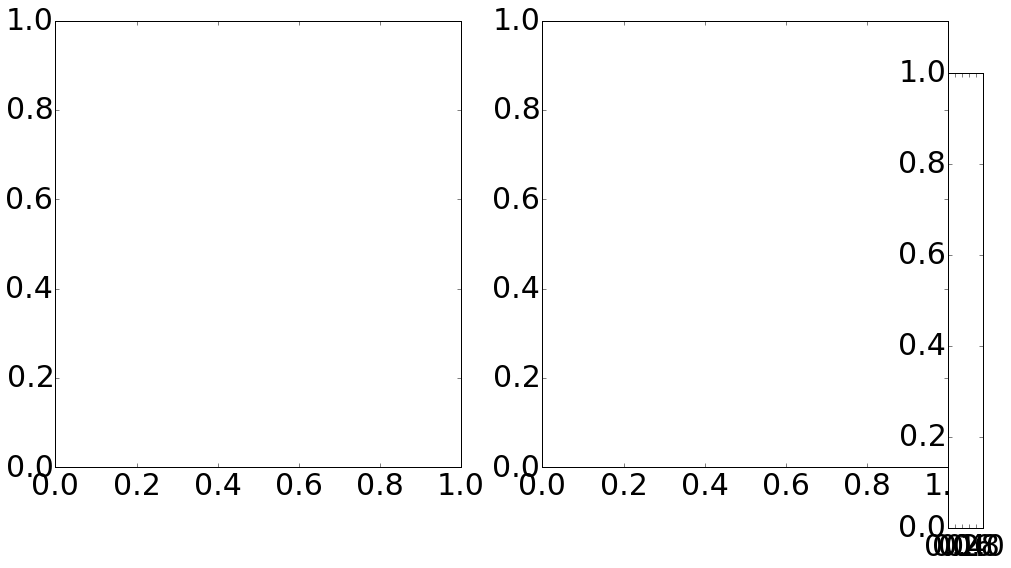

In [37]:
from matplotlib.colors import LogNorm
matplotlib.rcParams.update({'font.size': 30})

fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(16,8)
axcolor = fig.add_axes([0.90, 0.02, 0.03, 0.79])
for ax,hist in zip(axArr, [histDatum.h_raw for histDatum in ffluxHist2D.phase_zero_order_parameter_values.values()]):
    t = np.logspace(-4,10,base=10,num=20)
#     ax.plot((1,2),(3,4))
    im = ax.matshow(hist, cmap=cm.jet, origin='lower',norm=LogNorm())#, vmin=1e-8, vmax=1e-1)
#     for b in (25,-25):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
#     fig.colorbar(im, cax=axcolor, ticks=t, format='$%.2e$')
    ax.set_xlim(0,60)
    ax.set_ylim(0,60)
    ax.set_xlabel('copy num(A)')
#     ax.set_ylabel('copy num(B)')
axArr[0].set_ylabel('copy num(B)')
fig.colorbar(im, cax=axcolor)


In [8]:
bfHistNorm = example.bfHist.getCopy()
bfHistNorm.normalize()
bf1d = np.array((np.arange(-101,100),[bfHistNorm.h.trace(offset=i) for i in np.arange(-101,100)]))
ffluxHistNorm = example.ffluxHist.getCopy()
ffluxHistNorm.normalize()
fflux1d = np.array((np.arange(-101,100), ffluxHistNorm.h))
fflux1dzf = np.array((np.arange(-100,100), ffluxHistNorm.phase_n_order_parameter_values[('basin_id',0),('phase_id',0)].h_raw))
fflux1dzb = np.array((np.arange(-100,100), ffluxHistNorm.phase_n_order_parameter_values[('basin_id',1),('phase_id',0)].h_raw))
# fflux1d = np.array((np.arange(-100,101), [ffluxHistNorm.h.trace(offset=i) for i in np.arange(-100,101)]))
print(fflux1d[1].shape)

(201,)


Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4650874992
Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 197, in h5py._objects.ObjectID.__dealloc__ (/Users/travis/build/MacPython/h5py-wheels/h5py/h5py/_objects.c:4271)
KeyError: 4650874992


In [9]:
start,end=bf1d[0].searchsorted((-27,27))
print(start,end)
# bf1d[1,start:end]
np.linspace(-29,29,3)

74 128


array([-29.,   0.,  29.])

In [18]:
np.arange(-100,100).size

200

inf
6.33451171799e-05


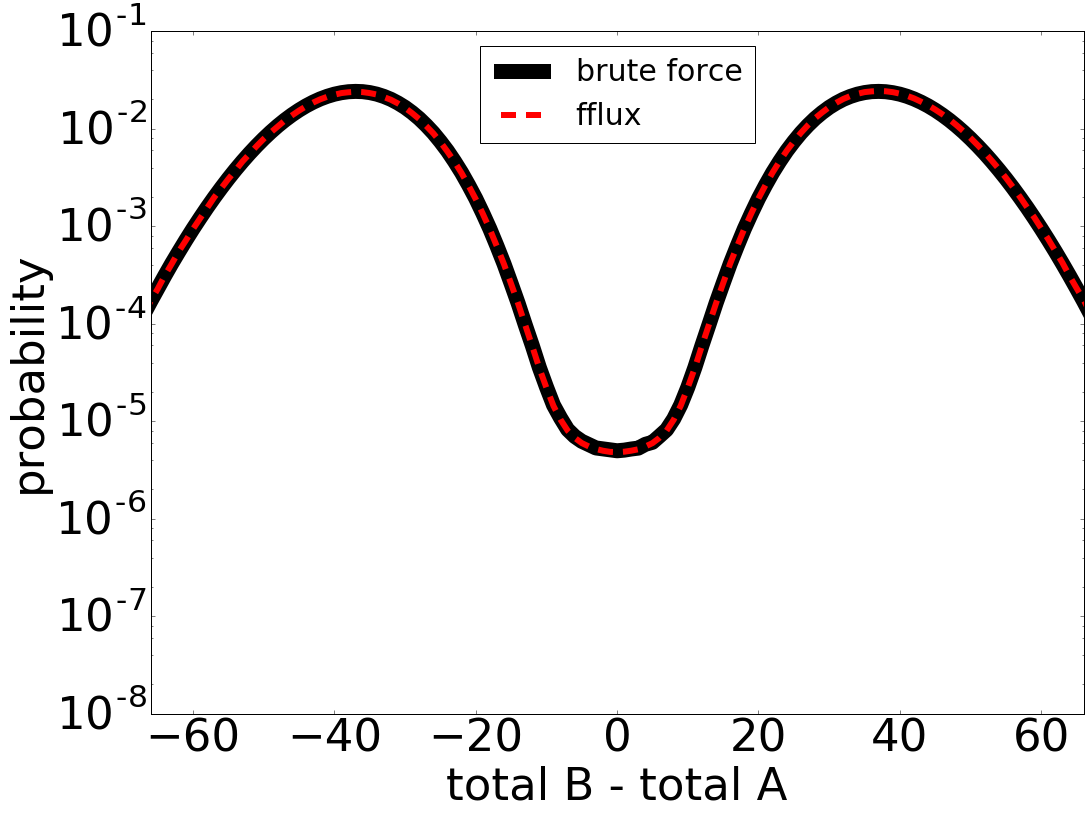

In [37]:
# normalized across everything
matplotlib.rcParams.update({'font.size': 45})
markerOpts = {'linestyle':'none',
              'marker':'o',
              'markerfacecolor':'none',
              'markersize':10}

import scipy.stats as st

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])

ax.plot(bf1d[0], bf1d[1]/bf1d[1].sum(), 'k', linewidth=15, label='brute force')  #zorder=1000,
ax.plot(fflux1d[0], fflux1d[1]/fflux1d[1].sum(), 'r--', linewidth=6, dashes=(15,10), label='fflux')
# for b in np.linspace(-27,27,13):
#     ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
# for b in [-27,-25,-22,-18,-14,-12,-8,-5,-2,0,10,20]:
#     ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='upper center', fontsize=30)#bbox_to_anchor=(0.8, 0.8))  #loc='upper right')
ax.set_xlim(-66,66)
ax.set_ylim(1e-8,1e-1)
ax.set_yscale('log')
ax.set_xlabel('total B - total A')
ax.set_ylabel('probability')
# ax.set_title('1D probability landscape of genetic toggle switch', y=1.05);
print(st.entropy(pk=bf1d[1]/bf1d[1].sum(), qk=fflux1d[1]/fflux1d[1].sum()))
print(st.entropy(pk=bf1d[1][35:165]/bf1d[1][35:165].sum(), qk=fflux1d[1][35:165]/fflux1d[1][35:165].sum()))

In [31]:
def ticks_format(value, index):
    """
    get the value and returns the value as:
       integer: [0,99]
       1 digit float: [0.1, 0.99]
       n*10^m: otherwise
    To have all the number of the same size they are all returned as latex strings
    """
    exp = np.floor(np.log10(value))
    base = value/10**exp
    if exp == 0 or exp == 1:   
        return '${0:d}$'.format(int(value))
    if exp == -1:
        return '${0:.1f}$'.format(value)
    else:
        return '${0:d}\\cdot10^{{{1:d}}}$'.format(int(base), int(exp))



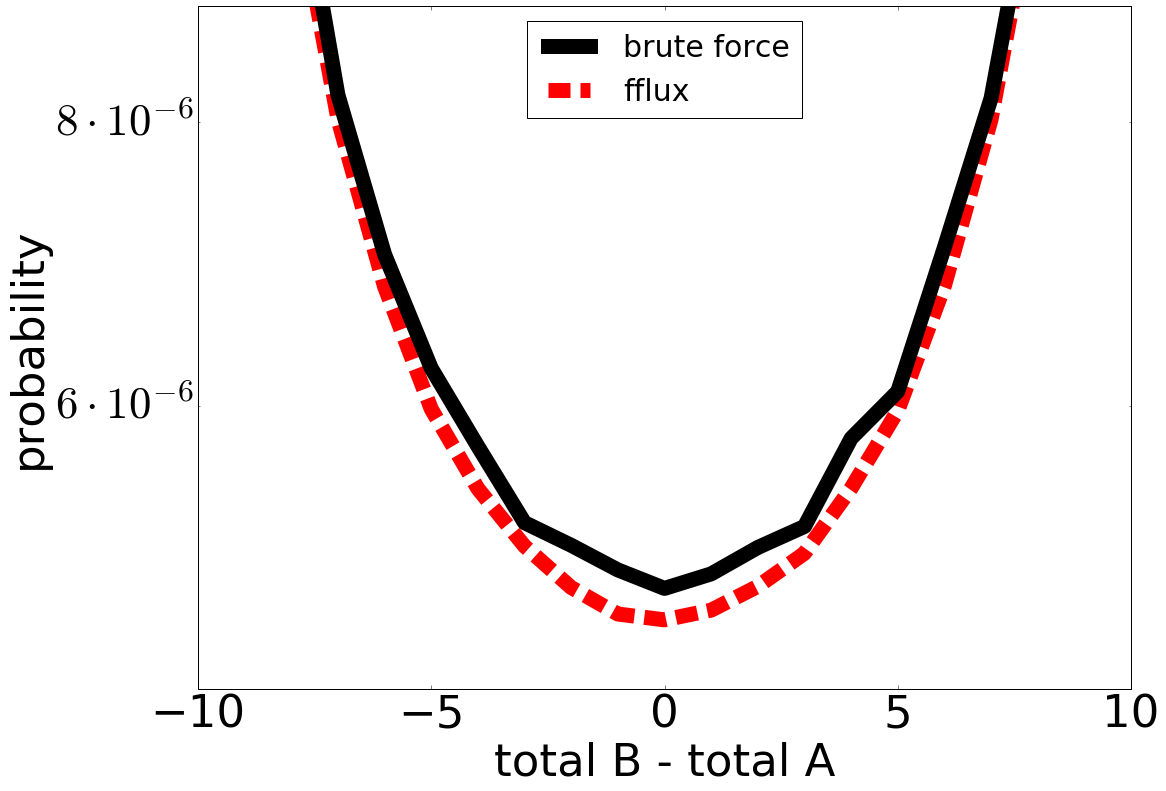

In [38]:
# normalized over everything

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])

ax.plot(bf1d[0], bf1d[1]/bf1d[1].sum(), 'k', linewidth=15, label='brute force', zorder=1000)
ax.plot(fflux1d[0], fflux1d[1]/fflux1d[1].sum(), 'r--', linewidth=15, dashes=(22,10), label='fflux')
# for b in np.linspace(-27,27,13):
#     ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='upper center', fontsize=30)
ax.set_yscale('log')
yrange = (4.5e-6,9e-6)
ax.set_ylim(*yrange)

subs = [2,4,6,8]  # ticks to show per decade
ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(subs=subs)) #set the ticks position
ax.yaxis.set_major_formatter(matplotlib.ticker.NullFormatter())   # remove the major ticks
ax.yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(ticks_format))  #add the custom ticks


# ax.get_yaxis().get_major_formatter().labelOnlyBase = False
# ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
# ax.set_yticks([10**-5.3,10**-5.1])
# ax.set_yticklabels(np.logspace(*myrange, num=5))
ax.set_xlim(-10, 10)

ax.set_xlabel('total B - total A');
ax.set_ylabel('probability');
# ax.set_title('1D probability landscape of genetic toggle switch\n transition region only', y=1.05);

# print(st.entropy(pk=bf1dTrans[1]/bf1dTrans[1].sum(), qk=fflux1dTrans[1]/fflux1dTrans[1].sum()))

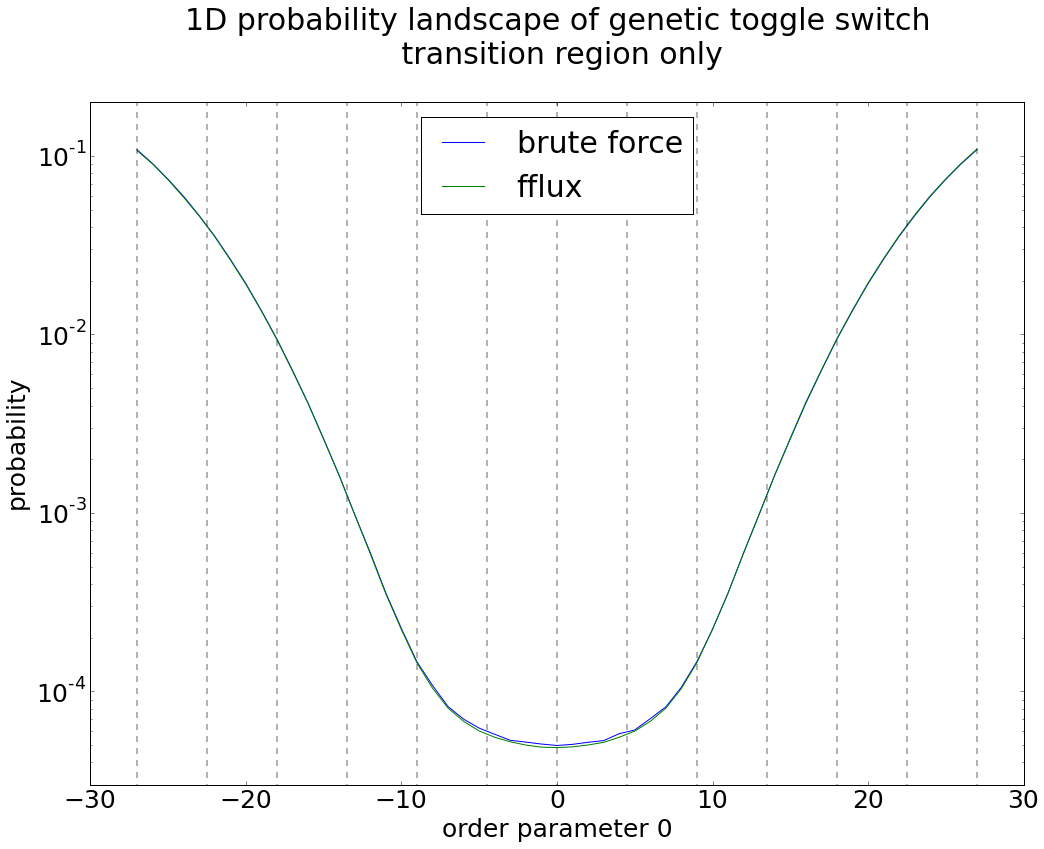

In [21]:
# normalized over xmin-xmax

xmin,xmax=-27,27
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1dTrans = fflux1d[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum(), label='brute force')
ax.plot(fflux1dTrans[0], fflux1dTrans[1]/fflux1dTrans[1].sum(), label='fflux')
for b in np.linspace(-27,27,13):
    ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(3e-5,2e-1)
ax.set_xlim(-30, 30)

ax.set_xlabel('order parameter 0');
ax.set_ylabel('probability');
ax.set_title('1D probability landscape of genetic toggle switch\n transition region only', y=1.05);

# print(st.entropy(pk=bf1dTrans[1]/bf1dTrans[1].sum(), qk=fflux1dTrans[1]/fflux1dTrans[1].sum()))

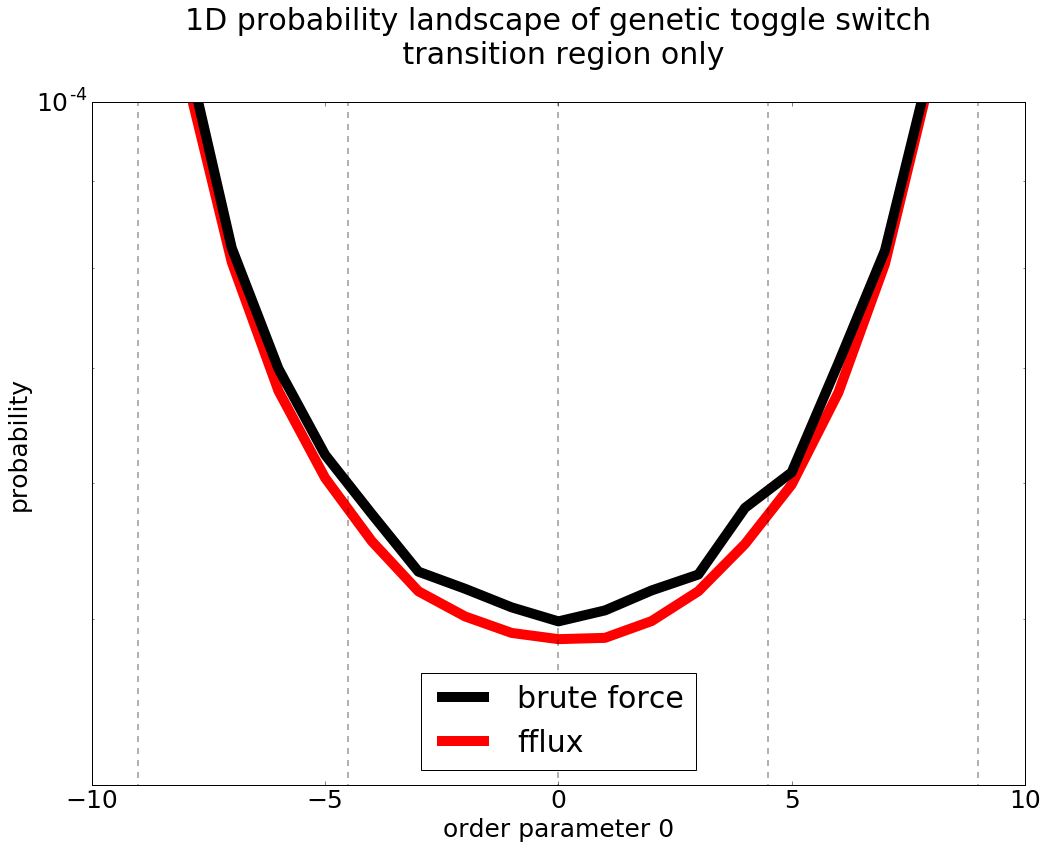

In [58]:
# normalized over xmin-xmax

xmin,xmax=-27,27
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1dTrans = fflux1d[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])

ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum(), 'k', linewidth=10, label='brute force', zorder=1000)
ax.plot(fflux1dTrans[0], fflux1dTrans[1]/fflux1dTrans[1].sum(), 'r', linewidth=10, label='fflux')
for b in np.linspace(-27,27,13):
    ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(4e-5,1e-4)
ax.set_xlim(-10, 10)

ax.set_xlabel('total B - total A');
ax.set_ylabel('probability\n(normalized over $x=-27->27$)');
ax.set_title('1D probability landscape of genetic toggle switch\n transition region only', y=1.05);

# print(st.entropy(pk=bf1dTrans[1]/bf1dTrans[1].sum(), qk=fflux1dTrans[1]/fflux1dTrans[1].sum()))

In [ ]:
f = figure(figsize=(18,12))
ax = f.gca()

ax.plot()

[   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    2.    2.    6.    5.    7.    5.    5.   11.   22.   21.   18.   34.   30.   37.   64.   71.   87.  149.  140.  184.  182.  249.  257.  334.  377.  378.  407.  437.  443.  434.  459.  500.  530.  451.  443.  472.  393.  355.  357.  311.  271.  221.  194.  133.  122.  103.   85.   51.   44.   29.   25.   16.   20.    9.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    

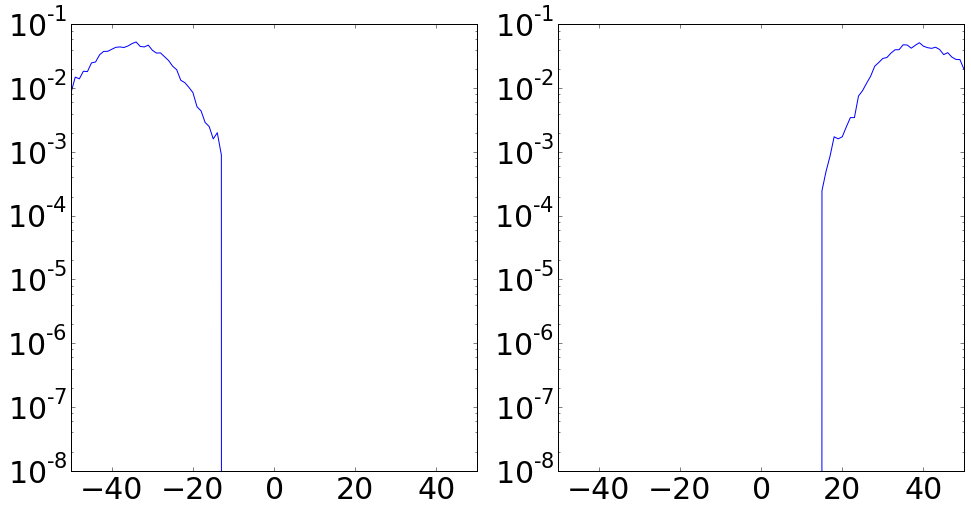

In [8]:
from matplotlib.colors import LogNorm
matplotlib.rcParams.update({'font.size': 30})

fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(16,8)
for ax,hist in zip(axArr, (fflux1dzf,fflux1dzb)):
    print(hist[1])
    im = ax.plot(hist[0], hist[1]/hist[1].sum())
    ax.set_ylim(1e-8,1e-1)
    ax.set_xlim(-50, 50)
    ax.set_yscale('log')

In [9]:
# normalized over -5,5

xmin,xmax=-35,35
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1d_wi04Trans = fflux1d_wi04[:,s:e]
fflux1d_wi1Trans = fflux1d_wi1[:,s:e]
fflux1d_wi4Trans = fflux1d_wi4[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1][-5-xmin:6-xmin].sum(), label='brute force')
ax.plot(fflux1d_wi04Trans[0], fflux1d_wi04Trans[1]/fflux1d_wi04Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 0.4')
ax.plot(fflux1d_wi1Trans[0], fflux1d_wi1Trans[1]/fflux1d_wi1Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 1.0')
ax.plot(fflux1d_wi4Trans[0], fflux1d_wi4Trans[1]/fflux1d_wi4Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 4.0')
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(1e-3,1e3)
ax.set_xlim(xmin, xmax)

NameError: name 'fflux1d_wi04' is not defined

In [ ]:
xmin,xmax=-100,100
s,e=bf1d[0].searchsorted((xmin,xmax))
bf1dTrans = bf1d[:,s:e]
fflux1dTrans = fflux1d[:,s:e]

f = figure(figsize=(12,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum())
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee3.ffluxHist.h)
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee4.ffluxHist.h)
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee5.ffluxHist.h)
# ax.plot(example.ffluxHist.h.trace())
ax.set_yscale('log')
ax.set_xlim(-25, 25)

In [ ]:
examplee5.ffluxHist.h[1:-1]

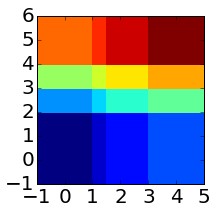

In [15]:
fig = plt.figure(figsize=(3,3))
ax = fig.gca()

xedges = [-1, 1, 1.5, 3, 5]
yedges = [-1, 2, 3, 4, 6]
H = np.ones((4,4)).cumsum().reshape(4, 4)
X, Y = np.meshgrid(xedges, yedges)
ax.pcolormesh(X, Y, H)